# Jaguar Re-Identification - ResNet-34 Baseline

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1773415013.897402   32810 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773415014.000051   32810 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773415015.294126   32810 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1773415016.518372   32810 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR = os.path.join(DATA_DIR, 'cleaned')
TRAIN_IMG_DIR = os.path.join(CLEANED_DIR, 'train')
TEST_IMG_DIR = os.path.join(CLEANED_DIR, 'test')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR = r'C:\tf\logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Data loading

In [3]:
train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_split.csv'))
val_df = pd.read_csv(os.path.join(CLEANED_DIR, 'val_split.csv'))
test_pairs_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"Test pairs: {len(test_pairs_df)}")

Train: 1516 images
Val:   379 images
Test pairs: 137270


In [4]:
def load_images_from_df(df, img_dir):
    images, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(os.path.join(img_dir, row['filename'])).convert('RGB')
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

def load_test_images(img_dir):
    test_images = {}
    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            test_images[fname] = np.array(img, dtype=np.float32) / 255.0
    return test_images

print("Loading images...")
X_train, y_train = load_images_from_df(train_df, TRAIN_IMG_DIR)
X_val, y_val = load_images_from_df(val_df, TRAIN_IMG_DIR)
test_images = load_test_images(TEST_IMG_DIR)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, test: {len(test_images)}")

Loading images...
X_train: (1516, 224, 224, 3), X_val: (379, 224, 224, 3), test: 371


## 2. ResNet-34 architecture

ResNet-34 from scratch, following the residual pattern from `create_small_residual_conv_net`.  
- Initial: Conv2D(64, 7x7, stride 2) + MaxPool => 56x56x64  
- Layer1: 3 residual blocks (64 filters) => 56x56x64  
- Layer2: 4 residual blocks (128 filters, first stride 2) => 28x28x128  
- Layer3: 6 residual blocks (256 filters, first stride 2) => 14x14x256  
- Layer4: 3 residual blocks (512 filters, first stride 2) => 7x7x512  
- GlobalAveragePooling2D -> Dense(31, softmax)

In [5]:
def residual_block(x, filters, stride=1):
    prev_x = x

    x = keras.layers.Conv2D(filters, (3, 3), strides=(stride, stride), padding='same', activation=keras.activations.tanh)(x)
    x = keras.layers.Conv2D(filters, (3, 3), strides=(1, 1), padding='same', activation=keras.activations.tanh)(x)

    if stride != 1 or prev_x.shape[-1] != filters:
        prev_x = keras.layers.Conv2D(filters, (1, 1), strides=(stride, stride), padding='valid', activation=keras.activations.linear)(prev_x)

    x = keras.layers.Add()([prev_x, x])
    return x


def create_resnet34(input_shape, num_classes):
    input_tensor = keras.Input(input_shape)  # 224, 224, 3

    x = input_tensor

    # Initial conv + pool
    x = keras.layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation=keras.activations.tanh)(x)
    # 112, 112, 64
    x = keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    # 56, 56, 64

    # Layer 1: 3 blocks, 64 filters
    for _ in range(3):
        x = residual_block(x, 64)
    # 56, 56, 64

    # Layer 2: 4 blocks, 128 filters (first with stride 2)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)
    # 28, 28, 128

    # Layer 3: 6 blocks, 256 filters (first with stride 2)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)
    # 14, 14, 256

    # Layer 4: 3 blocks, 512 filters (first with stride 2)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)
    # 7, 7, 512

    # Head
    x = keras.layers.GlobalAveragePooling2D()(x)
    # 512
    output_tensor = keras.layers.Dense(num_classes, activation=keras.activations.softmax)(x)

    model = keras.Model(input_tensor, output_tensor)
    return model

resnet = create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
resnet.summary()

W0000 00:00:1773415018.102079   32810 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773415018.232965   32810 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12294 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,928 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 56, 56,    │          0 │ add[0][0],        │
│                     │ 64)               │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │     36,928 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 56, 56,    │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 56, 56,    │          0 │ add_1[0][0],      │
│                     │ 64)               │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │     73,856 │ add_2[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 28, 28,    │      8,320 │ add_2[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 28, 28,    │          0 │ conv2d_9[0][0],   │
│                     │ 128)              │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │    147,584 │ add_3[0][0]     

 Total params: 21,292,063 (81.22 MB)

 Trainable params: 21,292,063 (81.22 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [6]:
resnet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_log_dir = os.path.join(LOG_DIR, 'resnet34_baseline', datetime.now().strftime('%Y%m%d-%H%M%S'))

resnet_history = resnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.TensorBoard(log_dir=resnet_log_dir, histogram_freq=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/50


I0000 00:00:1773415030.135518   32912 service.cc:153] XLA service 0x7ff664053f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773415030.135560   32912 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773415030.216816   32912 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773415030.905479   32912 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773415030.929360   32912 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12329__.56


 3/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.0295 - loss: 10.5497    

I0000 00:00:1773415038.861997   32912 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0577 - loss: 21.8016

I0000 00:00:1773415041.384561   32913 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12329__.56


48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 216ms/step - accuracy: 0.0686 - loss: 16.5842 - val_accuracy: 0.0449 - val_loss: 4.8923
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.0877 - loss: 4.2978 - val_accuracy: 0.0923 - val_loss: 3.6961
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.0798 - loss: 3.8085 - val_accuracy: 0.0950 - val_loss: 3.5899
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.0891 - loss: 3.6223 - val_accuracy: 0.0950 - val_loss: 3.5318
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.0805 - loss: 3.5269 - val_accuracy: 0.0950 - val_loss: 3.4715
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.0884 - loss: 3.4852 - val_accuracy: 0.0950 - val_loss: 3.4888
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.0864 - loss: 3.4764 - val_accuracy: 0.0950 - val_loss: 3.5120
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.0831 - loss: 3.4511 - val_accuracy: 0.0950 - val_loss:

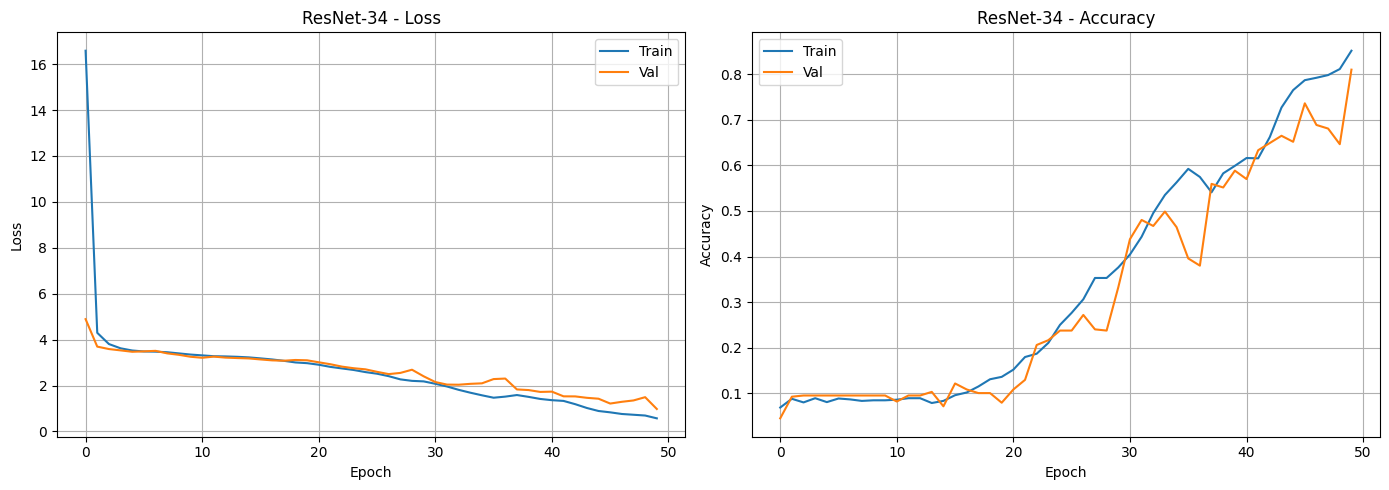

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resnet_history.history['loss'], label='Train')
axes[0].plot(resnet_history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ResNet-34 - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(resnet_history.history['accuracy'], label='Train')
axes[1].plot(resnet_history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('ResNet-34 - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet34_baseline_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
train_loss, train_acc = resnet.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = resnet.evaluate(X_val, y_val, verbose=0)

print(f"ResNet-34 baseline:")
print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

ResNet-34 baseline:
  Train - Loss: 0.3914, Acc: 0.9037
  Val   - Loss: 0.9792, Acc: 0.8100


## 4. Submission

In [9]:
final_resnet = create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
final_resnet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

all_train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_clean.csv'))
X_all, y_all = load_images_from_df(all_train_df, TRAIN_IMG_DIR)

best_epoch = np.argmin(resnet_history.history['val_loss']) + 1
print(f"Best epoch from val: {best_epoch}")

final_resnet.fit(
    X_all, y_all,
    epochs=best_epoch,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"Final train accuracy: {final_resnet.evaluate(X_all, y_all, verbose=0)[1]:.4f}")

Best epoch from val: 50
Epoch 1/50


I0000 00:00:1773415195.874787   32911 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_571118__.56


59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0641 - loss: 18.4791

I0000 00:00:1773415201.314054   32911 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_571118__.56
I0000 00:00:1773415201.825867   38453 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 16 bytes spill stores, 16 bytes spill loads



60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step - accuracy: 0.0580 - loss: 12.1134
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.0707 - loss: 3.5565
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.0707 - loss: 3.5317
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.0723 - loss: 3.4715
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.0739 - loss: 3.4306
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.0828 - loss: 3.3891
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.0828 - loss: 3.3410
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.0929 - loss: 3.3027
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.0971 - loss: 3.2555
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.0950 - loss: 3.2082
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1024 - loss: 3.1526
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.1029 

In [10]:
embedding_model = keras.Model(
    inputs=final_resnet.input,
    outputs=final_resnet.layers[-2].output
)

test_filenames = sorted(test_images.keys())
test_array = np.array([test_images[f] for f in test_filenames])

test_embeddings = embedding_model.predict(test_array, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embeddings shape: {test_embeddings.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step
Embeddings shape: (371, 512)


In [11]:
query_idx = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.sum(
    test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx],
    axis=1
)
similarities = np.clip(similarities, 0, 1)

print(f"Similarities: {len(similarities)} pairs")
print(f"Min: {similarities.min():.4f}, Max: {similarities.max():.4f}, Mean: {similarities.mean():.4f}")
print(f"Unique values: {len(np.unique(np.round(similarities, 4)))}")

Similarities: 137270 pairs
Min: 0.0000, Max: 0.9990, Mean: 0.3664
Unique values: 8531


In [12]:
submission = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

submission_path = os.path.join(SUBMISSION_DIR, 'submission_resnet34_baseline.csv')
submission.to_csv(submission_path, index=False)

print(f"Saved: {submission_path}")
display(submission.head(10))

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)

Saved: /home/franck/jaguar/submissions/submission_resnet34_baseline.csv


,row_id,similarity
0,0,0.865422
1,1,0.531322
2,2,0.571345
3,3,0.476764
4,4,0.721615
5,5,0.172839
6,6,0.464763
7,7,0.503670
8,8,0.245195
9,9,0.478399


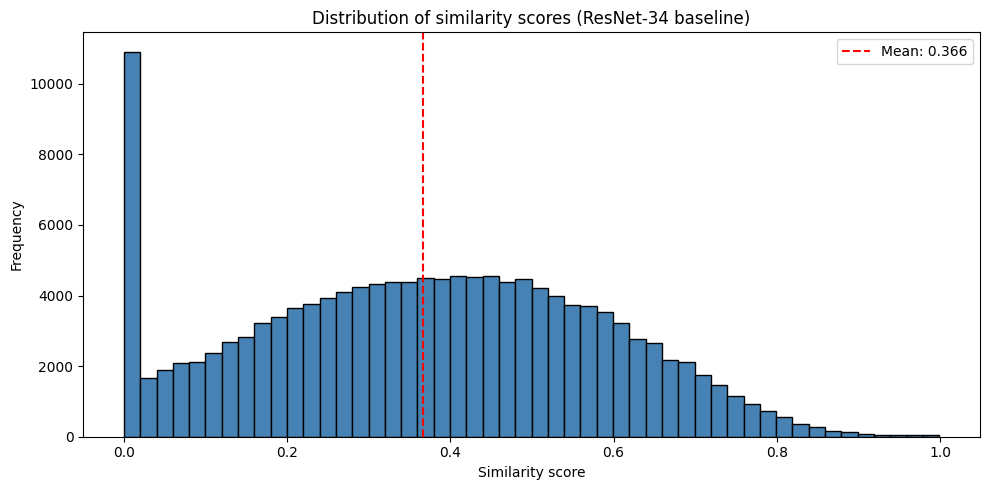

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel('Similarity score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of similarity scores (ResNet-34 baseline)')
ax.axvline(x=similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'similarity_distribution_resnet34.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

In [14]:
print(f"""
ResNet-34 baseline:
  Train: {train_acc:.4f}, Val: {val_acc:.4f}
  Best epoch: {best_epoch}
  Embedding dim: {test_embeddings.shape[1]}

vs CNN baseline (notebook 04):
  Train ~0.10, Val ~0.10
vs ViT baseline (notebook 05):
  Score Kaggle: 0.063

Submission -> {submission_path}
""")


ResNet-34 baseline:
  Train: 0.9037, Val: 0.8100
  Best epoch: 50
  Embedding dim: 512

vs CNN baseline (notebook 04):
  Train ~0.10, Val ~0.10
vs ViT baseline (notebook 05):
  Score Kaggle: 0.063

Submission -> /home/franck/jaguar/submissions/submission_resnet34_baseline.csv

